<a href="https://colab.research.google.com/github/putri-indahsari/skripsi/blob/main/Sentimen_Analisis_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen publik Program MBG di Youtube

Analisis sentimen adalah metode untuk mengklasifikasikan opini dalam bentuk teks menjadi kategori emosional seperti *positif*, *negatif*, atau *netral*. Pada proyek ini, dilakukan analisis terhadap **ulasan publik mengenai program mbg** yang diambil langsung dari Youtube melalui proses scraping menggunakan Python.

**Dataset:**
- **Sumber Data:** Youtube (scraping manual dari aplikasi Youtube)
- **Jumlah Data Awal:** 8663 ulasan
- **Setelah Preprocessing:** ... ulasan
- **Distribusi Kelas:**
  - **Negatif:** ±
  - **Positif:** ±
  - **Netral:** ±

## Import Library dan Data

In [ ]:
!pip install Sastrawi --quiet
!pip install nltk --quiet
!pip install transformers --quiet
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import torch
import re, string, requests
from io import StringIO
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from transformers import BertTokenizer, TFBertForSequenceClassification
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, Embedding, LSTM, Bidirectional
from keras.optimizers import Adam
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.callbacks import EarlyStopping
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')

<ipython-input-2-e65c3b4356e0>:26: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/all_data/halodoc_scraping.csv')

Mounted at /content/drive


## Data Explore dan Preprosessing Data Scraping

In [ ]:
jumlah_ulasan, jumlah_kolom = df.shape
print("Jumlah ulasan:", jumlah_ulasan)
print("Jumlah kolom:", jumlah_kolom)

Jumlah ulasan: 20000
Jumlah kolom: 1


In [ ]:
df.head()

,Review
0,pengalaman yg kurang mengenakkan.. mitra drive...
1,"Jujur, Halodoc tuh ngebantu banget! Gak perlu ..."
2,"saya mau pakai ""pengingat obat"" tp ternyata ga..."
3,pengalaman pertama ketika memakai aplikasi ini...
4,overall oke. Yang saya kurang suka adalah peng...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20000 non-null  object
dtypes: object(1)
memory usage: 156.4+ KB


In [ ]:
df.isna().sum()

,0
Review,0


In [ ]:
df.duplicated().sum()

np.int64(171)

In [ ]:
df.drop_duplicates(inplace=True)
print("Jumlah data setelah menghapus duplikat:", len(df))

Jumlah data setelah menghapus duplikat: 19829


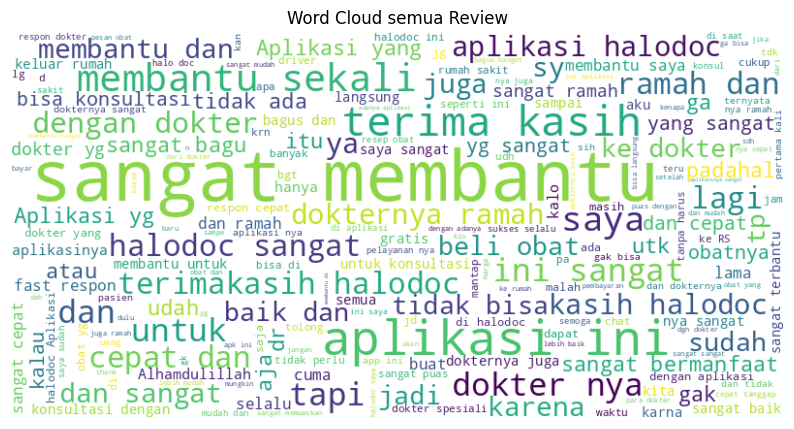

In [ ]:
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['Review']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.title('Word Cloud semua Review')
plt.axis('off')
plt.show()

In [ ]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.strip()

In [ ]:
def casefoldingText(text):
    return text.lower()

In [ ]:
def fix_slangwords(text):
    slangwords = {
        "abis": "habis", "bgt": "banget", "tp": "tapi", "tdk": "tidak", "gk": "tidak",
        "nggak": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "yg": "yang", "sy": "saya",
        "gue": "saya", "gw": "saya", "udh": "sudah", "sdh": "sudah", "uda": "sudah",
        "dr": "dari", "dgn": "dengan", "sm": "sama", "seharusnya": "harus", "aplikasiny": "aplikasi",
        "kpn": "kapan", "makasih": "terima kasih", "makasi": "terima kasih", "trus": "terus",
        "kalo": "kalau", "klo": "kalau", "pake": "pakai", "sulit": "susah", "susah": "ribet",
        "baik": "bagus", "bagus": "baik", "lol": "tertawa", "jln": "jalan", "smpe": "sampai",
        "gmn": "gimana", "pdhal": "padahal", "b aja": "biasa", "pas": "sedang", "guna": "berguna",
        "lg": "lagi", "bisa": "dapat", "trs": "terus", "bbrp": "beberapa", "td": "tadi",
        "krn": "karena", "dmn": "di mana", "sbnrnya": "sebenarnya", "aj": "saja", "aja": "saja",
        "cuma": "hanya", "cm": "cuma", "cmn": "cuma", "knp": "kenapa", "masi": "masih",
        "blm": "belum", "nyoba": "mencoba", "nyobain": "mencoba", "error": "gangguan",
        "bagu": "bagus", "jd": "jadi", "doang": "saja", "oke": "baik", "ok": "baik",
        "mantul": "mantap betul", "mantap": "bagus", "mantabh": "bagus", "mantabb": "bagus",
        "gaje": "tidak jelas", "dokternya": "dokter", "dok": "dokter", "cs": "customer service",
        "batalin": "batalkan", "janjiin": "janjikan", "respon": "tanggapan",
        "antri": "antre", "lamaa": "lama", "pelayanannya": "pelayanan", "obatnya": "obat",
        "gabisa": "tidak bisa", "gaboleh": "tidak boleh", "gabung": "bergabung",
        "notif": "notifikasi", "fiturnya": "fitur", "rekom": "rekomendasi"
    }

    words = text.split()
    return ' '.join([slangwords.get(word.lower(), word) for word in words])


In [ ]:
def tokenizingText(text):
    return re.findall(r'\b\w+\b', text)

In [ ]:
def filteringText(text_tokens):
    listStopwords = set(stopwords.words('indonesian') + stopwords.words('english'))
    listStopwords.update([

    'halodoc', 'aplikasi', 'ini', 'saya', 'dan', 'yg', 'yang', 'untuk', 'juga', 'aja', 'lagi', 'itu',
    'ke', 'dengan', 'karena', 'sudah', 'atau', 'kalau', 'jadi', 'tapi', 'kalo', 'tp', 'padahal',
    'beli', 'jd', 'bisa', 'tidak', 'gak', 'ada', 'di', 'sy', 'sih', 'lagi', 'kalau', 'aja',
    'ke', 'yg', 'yang','konsul','driver', 'itu', 'saya', 'udah','sudah', 'jika', 'kalo', 'karna', 'mau', 'cuma',
    'terima', 'kasih', 'terimakasih', 'makasih', 'dokternya', 'dokterny', 'dokter nya',
    'dokternya', 'dokter', 'nya', 'konsultasi', 'cepat', 'dan', 'baik', 'sekali','ya','moga','jg','sya','obat'
    ])
    return [word for word in text_tokens if word not in listStopwords]

In [ ]:
def toSentence(list_words):
    return ' '.join(list_words)

In [ ]:
stemmer = StemmerFactory().create_stemmer()
def stemmingText(text):
    return stemmer.stem(text)

In [ ]:
df['clean_text'] = df['Review'].apply(cleaningText)
df['clean_text'] = df['clean_text'].apply(casefoldingText)
df['clean_text'] = df['clean_text'].apply(fix_slangwords)
df['tokens'] = df['clean_text'].apply(tokenizingText)
df['tokens'] = df['tokens'].apply(filteringText)
df['text_final'] = df['tokens'].apply(toSentence)
df['text_final'] = df['text_final'].apply(stemmingText)

In [ ]:
lex_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
lex_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

df_pos = pd.read_csv(StringIO(lex_pos.text))
df_neg = pd.read_csv(StringIO(lex_neg.text))

pos_col = df_pos.columns[0]
neg_col = df_neg.columns[0]

positive_words = set(df_pos[pos_col])
negative_words = set(df_neg[neg_col])

def label_sentiment(text):
    tokens = text.split()
    pos_count = sum(1 for word in tokens if word in positive_words)
    neg_count = sum(1 for word in tokens if word in negative_words)
    if pos_count > neg_count:
        return 'positif'
    elif neg_count > pos_count:
        return 'negatif'
    else:
        return 'netral'

df['label'] = df['text_final'].apply(label_sentiment)
df = df[df['label'].isin(['positif', 'negatif', 'netral'])]

analisis sentimen ulasan aplikasi Halodoc di Google Play Store dengan metode leksikon. Caranya, saya ambil daftar kata positif dan negatif, lalu hitung berapa banyak kata positif dan negatif di setiap kalimat. Kalau salah satu lebih banyak, maka sentimennya saya beri label netral

Distribusi Sentimen:
label
positif    10782
netral      5314
negatif     3733
Name: count, dtype: int64


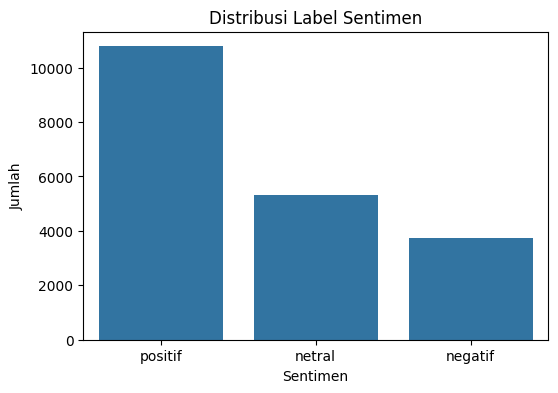

In [ ]:
sentiment_counts = df['label'].value_counts()
print("Distribusi Sentimen:")
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

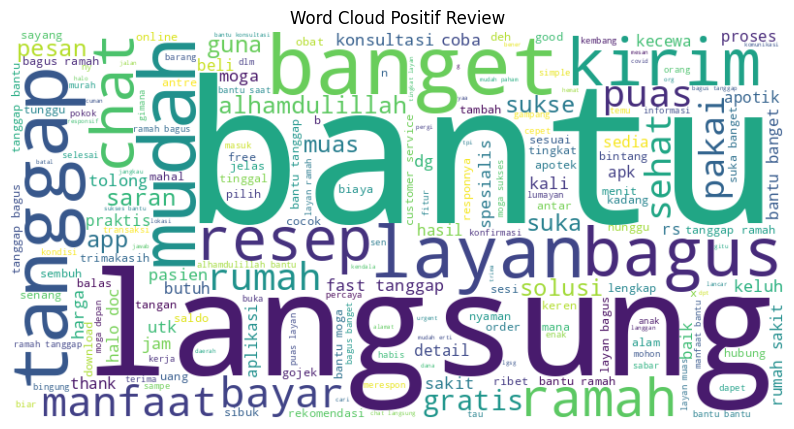

In [ ]:
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['label'] == 'positif']['text_final']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Word Cloud Positif Review')
plt.axis('off')
plt.show()

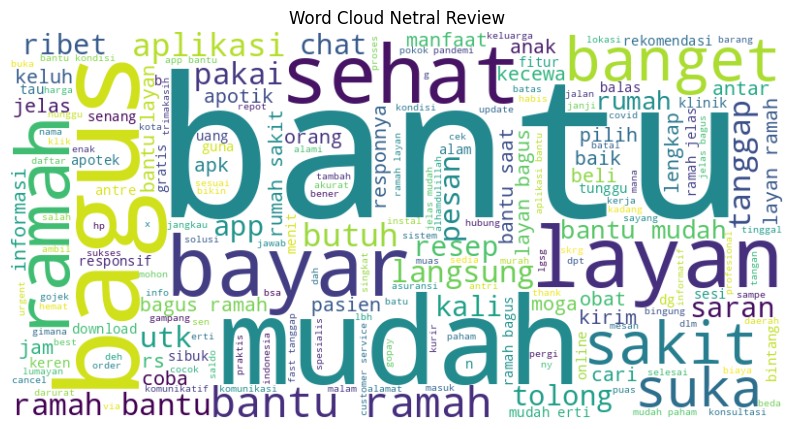

In [ ]:
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['label'] == 'netral']['text_final']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neutral, interpolation='bilinear')
plt.title('Word Cloud Netral Review')
plt.axis('off')
plt.show()

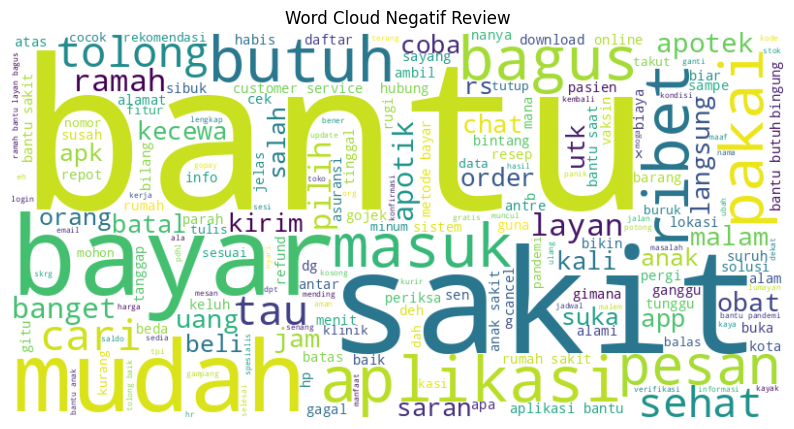

In [ ]:
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['label'] == 'negatif']['text_final']))
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Word Cloud Negatif Review')
plt.axis('off')
plt.show()

In [ ]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

 labels = ['negatif', 'netral', 'positif']

In [ ]:
df=df.dropna(subset=['text_final'])

In [ ]:
df['text_final']=df['text_final'].astype(str)

In [ ]:
df.head()

,Review,clean_text,tokens,text_final,label,label_encoded
0,pengalaman yg kurang mengenakkan.. mitra drive...,pengalaman yang kurang mengenakkan mitra drive...,"[pengalaman, mengenakkan, mitra, drivernya, be...",alam enak mitra drivernya ganti tutup apotek c...,negatif,0
1,"Jujur, Halodoc tuh ngebantu banget! Gak perlu ...",jujur halodoc tuh ngebantu banget tidak perlu ...,"[jujur, tuh, ngebantu, banget, ribet, antre, r...",jujur tuh ngebantu banget ribet antre rumah sa...,positif,2
2,"saya mau pakai ""pengingat obat"" tp ternyata ga...",saya mau pakai pengingat obat tapi ternyata ti...,"[pakai, pengingat, bs, diubah, kali, sehari, b...",pakai ingat bs ubah kali hari bs ubah ubah jam...,negatif,0
3,pengalaman pertama ketika memakai aplikasi ini...,pengalaman pertama ketika memakai aplikasi ini...,"[pengalaman, memakai, pesanan, langsung, dibat...",alam pakai pesan langsung batal notifikasi pem...,negatif,0
4,overall oke. Yang saya kurang suka adalah peng...,overall baik yang saya kurang suka adalah peng...,"[overall, suka, pengiriman, dibedakan, instan,...",overall suka kirim beda instan reguler sehat u...,positif,2


In [ ]:
df_preprocessed =  df[['Review', 'text_final', 'label', 'label_encoded']]
file_path = 'ulasan_label.csv'
df_preprocessed.to_csv(file_path, index=False)

In [ ]:
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
jumlah_ulasan, jumlah_kolom = df.shape
print("Jumlah data setelah preprocessing:", jumlah_ulasan)

Jumlah data setelah preprocessing: 19829


## Skema Pelatihan

### Deep Learning ANN Algoritma 80 20 TF-IDF (KERAS TUNER)

In [ ]:
y = df['label_encoded']

In [ ]:
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 1))
X_tfidf = vectorizer.fit_transform(df['text_final'])
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, stratify=y, test_size=0.2, random_state=42)

 TF-IDF (Term Frequency–Inverse Document Frequency) adalah metode untuk mengubah teks menjadi representasi numerik (vektor), berdasarkan seberapa penting sebuah kata dalam dokumen dan seluruh korpus.

In [ ]:
X_train_dl = X_train.toarray()
X_test_dl = X_test.toarray()

.toarray() mengubah sparse matrix tersebut menjadi array NumPy berdimensi penuh (dense matrix)

In [ ]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))

beri bobot ke kelas minor


In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train_dl.shape[1],)))
    model.add(Dense(hp.Int('units1', min_value=64, max_value=512, step=64), activation='relu'))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))
    model.add(Dense(hp.Int('units2', min_value=32, max_value=256, step=32), activation='relu'))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(3, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', values=[1e-3, 3e-4])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='segmentasi_halodoc'
)

tuner.search(X_train_dl, y_train,
             validation_split=0.2,
             epochs=100,
             batch_size=32,
             class_weight=class_weights,
             callbacks=[EarlyStopping(monitor='val_accuracy', patience=5)],
             verbose=1)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Skema 1 Deep Learning + TF-IDF (Tuning)")
print(best_hp.values)

Trial 20 Complete [00h 00m 31s]
val_accuracy: 0.9290891885757446

Best val_accuracy So Far: 0.9360226988792419
Total elapsed time: 00h 09m 40s
Skema 1 Deep Learning + TF-IDF (Tuning)
{'units1': 448, 'dropout1': 0.2, 'units2': 64, 'dropout2': 0.4, 'lr': 0.0003}


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
train_acc = best_model.evaluate(X_train_dl, y_train, verbose=0)[1]
test_acc = best_model.evaluate(X_test_dl, y_test, verbose=0)[1]
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9793859720230103
Test Accuracy: 0.9331820607185364


124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       747
           1       0.86      0.90      0.88      1063
           2       0.98      0.96      0.97      2156

    accuracy                           0.93      3966
   macro avg       0.92      0.92      0.92      3966
weighted avg       0.93      0.93      0.93      3966



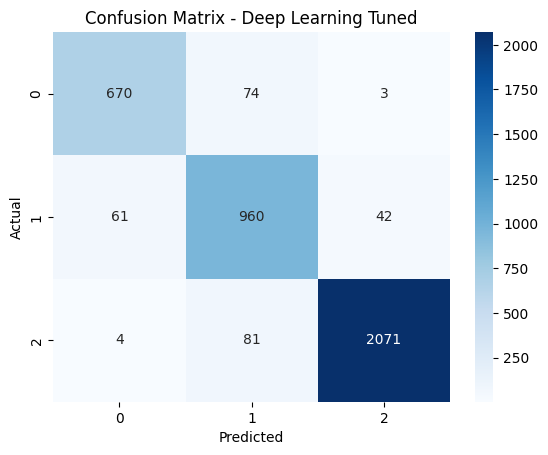

In [ ]:
pred_dl = np.argmax(best_model.predict(X_test_dl), axis=1)
print(classification_report(y_test, pred_dl))
sns.heatmap(confusion_matrix(y_test, pred_dl), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Deep Learning Tuned')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

- **Precision**: Proporsi prediksi positif yang benar  
  `Precision = TP / (TP + FP)`

  Tinggi → model jarang salah mengira yang negatif sebagai positif.

  Fokus pada akurasi hasil positif yang diprediksi

- **Recall**: Proporsi kasus positif yang berhasil ditemukan  
  `Recall = TP / (TP + FN)`

  Tinggi → model berhasil menangkap semua yang seharusnya positif.
  
  Fokus pada kemampuan model menemukan positif aktual.

- **F1-Score**: Rata-rata antara precision & recall  
  `F1 = 2 * (Precision * Recall) / (Precision + Recall)`

In [ ]:
joblib.dump(vectorizer, 'tfidf_vectorizer.joblib')

['tfidf_vectorizer.joblib']

In [ ]:
best_model.save('dl_scema1.h5')

In [ ]:
best_model.save('dl_scema1.keras')

### SVM Algoritma 70 30 TF-IDF

In [ ]:
vectorizer_svm = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_svm = vectorizer_svm.fit_transform(df['text_final'])
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_svm, y, stratify=y, test_size=0.3, random_state=42)

In [ ]:
svm_model = SVC(C=10, kernel='linear', class_weight='balanced')
svm_model.fit(X_train_svm, y_train_svm)

SVC(C=10, class_weight='balanced', kernel='linear')

In [ ]:
train_acc_svm = svm_model.score(X_train_svm, y_train_svm)
test_acc_svm = svm_model.score(X_test_svm, y_test_svm)
print("Train Accuracy (SVM):", train_acc_svm)
print("Test Accuracy (SVM):", test_acc_svm)

Train Accuracy (SVM): 0.9989913544668588
Test Accuracy (SVM): 0.9332660951420407


              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1120
           1       0.86      0.92      0.89      1594
           2       0.98      0.96      0.97      3235

    accuracy                           0.93      5949
   macro avg       0.92      0.92      0.92      5949
weighted avg       0.94      0.93      0.93      5949



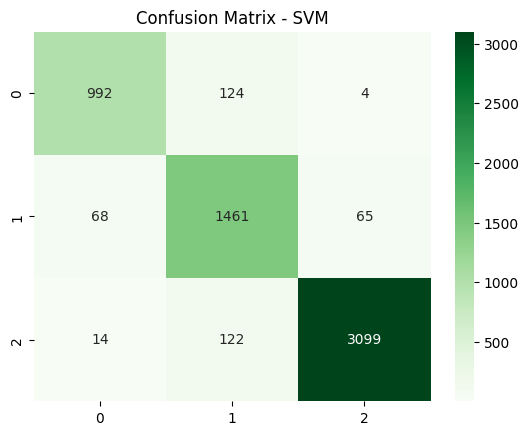

In [ ]:
pred_svm = svm_model.predict(X_test_svm)
print(classification_report(y_test_svm, pred_svm))
sns.heatmap(confusion_matrix(y_test_svm, pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - SVM')
plt.show()

In [ ]:
joblib.dump(svm_model, 'svm_model_tfidf.pkl')
joblib.dump(vectorizer_svm, 'tfidf_vectorizer_svm.pkl')

['tfidf_vectorizer_svm.pkl']

### Bidirectional LSTM Algoritma 90 10 Tokenization & Embedding (KERAS TUNER)

Trial 30 Complete [00h 01m 16s]
val_accuracy: 0.9462184906005859

Best val_accuracy So Far: 0.9462184906005859
Total elapsed time: 00h 43m 15s


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



📊 Skema LSTM Tuned
Best Hyperparameters: {'embed_dim': 150, 'lstm_units': 64, 'dropout1': 0.2, 'dense_units': 128, 'dropout2': 0.4, 'lr': 0.0003}
Train Accuracy: 0.9854869246482849
Test Accuracy: 0.9440242052078247
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       373
           1       0.89      0.91      0.90       532
           2       0.97      0.97      0.97      1078

    accuracy                           0.94      1983
   macro avg       0.94      0.93      0.93      1983
weighted avg       0.94      0.94      0.94      1983



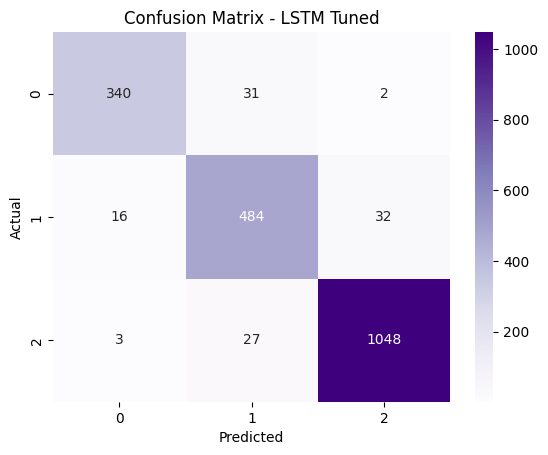

In [ ]:
max_words = 10000
max_len = 100
tokenizer_lstm = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df['text_final'])
X_seq = tokenizer_lstm.texts_to_sequences(df['text_final'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, stratify=y, test_size=0.1, random_state=42)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train), class_weights))


def build_lstm_model(hp):
    model = Sequential()
    model.add(Input(shape=(max_len,)))
    model.add(Embedding(input_dim=max_words, output_dim=hp.Choice('embed_dim', [100, 150, 200])))
    model.add(Bidirectional(LSTM(hp.Choice('lstm_units', [64, 128]), return_sequences=False)))
    model.add(Dropout(hp.Float('dropout1', 0.2, 0.5, step=0.1)))
    model.add(Dense(hp.Choice('dense_units', [32, 64, 128]), activation='relu'))
    model.add(Dropout(hp.Float('dropout2', 0.2, 0.5, step=0.1)))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 3e-4])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=30,
    executions_per_trial=1,
    directory='lstm_dir',
    project_name='lstm_1'
)

tuner.search(X_train, y_train,
             validation_split=0.2,
             epochs=100,
             batch_size=32,
             class_weight=class_weights,
             callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)],
             verbose=1)

best_model = tuner.get_best_models(1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]

print("\n📊 Skema LSTM Tuned")
print("Best Hyperparameters:", best_hp.values)

train_acc = best_model.evaluate(X_train, y_train, verbose=0)[1]
test_acc = best_model.evaluate(X_test, y_test, verbose=0)[1]
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

pred_lstm = np.argmax(best_model.predict(X_test), axis=1)
print(classification_report(y_test, pred_lstm))
sns.heatmap(confusion_matrix(y_test, pred_lstm), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - LSTM Tuned')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
best_model.save("model_lstm_tuned.h5")
best_model.save("model_lstm_tuned.keras")

In [ ]:
with open("tokenizer_lstm.pkl", "wb") as f:
    joblib.dump(tokenizer_lstm, f)

In [ ]:
params = {"max_words": max_words, "max_len": max_len}
with open("lstm_params.pkl", "wb") as f:
    joblib.dump(params, f)

## Results Final

### Skema 1: ANN + TF-IDF (Tuned)
- **Ekstraksi Fitur:** TF-IDF (2000 fitur)
- **Split Data:** 80:20 (train:test)
- **Model:** Sequential (3 Hidden Layers)
- **Tuning:** Keras Tuner ,Random Search (20 trials)
- **Akurasi:**
  - Train: ±97,94%
  - Test: ±93,32%

### Skema 2: SVM + TF-IDF
- **Ekstraksi Fitur:** TF-IDF (10000 fitur)
- **Split Data:** 70:30(training:testing)
- **Model:** Support Vector Machine (Linear)
- **Akurasi:**
  - Train: ±99,89%
  - Test: ±93,26%

### Skema 3: LSTM + Embedding (Tuned)
- **Ekstraksi Fitur:** Tokenizer + Embedding Layer
- **Split Data:** 90:10
- **Model:** Bidirectional LSTM
- **Tuning:** Keras Tuner
- **Best Hyperparameter:** 100-dim embed, LSTM 64, Dropout 0.2, LR 3e-4
- **Akurasi:**
  - Train: 98,59%
  - Test: 94,40%
- Sangat optimal karena akurasi tertinggi, f1-score seimbang antar kelas, memahami konteks kalimat, dan tidak overfit.

| Aspek | SVM (Support Vector Machine) | ANN (Artificial Neural Network) | Bidirectional LSTM (Tuned) |
|-------|-------------------------------|----------------------------------|----------------------------|
| **Tipe Model** | Model klasik (non-neural) | Feedforward Neural Network | Recurrent Neural Network (dua arah) |
| **Input** | TF-IDF (10000 fitur, unigram) | TF-IDF (10000 fitur, unigram) | Tokenizer (10000 kata) + Embedding + Padding (100) |
| **Urutan Data** | ❌ Tidak dipertimbangkan | ❌ Tidak dipertimbangkan | ✅ Diproses sebagai sekuens dari depan & belakang |
| **Pemrosesan Konteks** | ❌ Tidak bisa | ❌ Tidak bisa | ✅ Bisa (dengan konteks sebelum & sesudah kata) |
| **Kompleksitas** | Ringan | Sedang | Tinggi (butuh tuning & training lama) |
| **Kebutuhan Data** | Sedikit hingga sedang | Sedang | Banyak (agar tidak overfitting) |
| **Akurasi (test)** | **93.26%** | 93.01% | **💡 94.40% (Tertinggi)** |
| **Overfitting** | ✅ Mudah dikontrol (C=10, class_weight) | ⚠️ Mulai overfit di epoch akhir | ✅ Terkontrol dengan dropout dan early stopping |
| **Cocok Untuk** | Text classification, baseline NLP | Tugas klasifikasi numerik/fitur tetap | Sentimen, teks panjang, urutan kata penting |
| **Kelebihan** | Cepat, presisi bagus untuk data TF-IDF | Implementasi mudah, performa cukup stabil | Memahami konteks, performa tertinggi secara umum |
| **Kelemahan** | Tidak memahami urutan/konteks kata | Tidak cocok jika konteks penting | Waktu training lama, rawan overfit tanpa tuning |


### Kesimpulan:
- Dataset valid hasil scraping mandiri (19.829 sampel dari 20.000+ data mentah)
- Tiga skema pelatihan model digunakan, masing-masing dengan variasi fitur, algoritma, dan split data
- Seluruh skema menghasilkan akurasi **test set ≥ 85%**, dan salah satu skema (LSTM) memiliki **akurasi training dan testing ≥ 94%**
- Struktur label tiga kelas: negatif, netral, positif




In [ ]:
!pip freeze

absl-py==1.4.0
accelerate==1.7.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.1
altair==5.5.0
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.9.0
argon2-cffi==25.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.2
arviz==0.21.0
astropy==7.1.0
astropy-iers-data==0.2025.6.2.0.38.23
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.5.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.0.0
blosc2==3.3.4
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.4.26
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.2
chex==0.1.89
clarabel==0.11.0
click==8.2.1
cloudpathlib==0.21.1
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy